# **Machine Learning Based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence**

In [89]:
!pip install streamlit

In [90]:
# Import required libraries
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [91]:
clients = pd.read_csv('/content/clients.csv')
properties = pd.read_csv('/content/properties.csv')


print("Clients Dataset:", clients.shape)
print("Properties Dataset:", properties.shape)

Clients Dataset: (2000, 12)
Properties Dataset: (10000, 9)


## 1. Import Libraries

In [92]:
# Check dataset information
print("Clients Dataset")
print("Shape:", clients.shape)
print("\nMissing Values:")
print(clients.isnull().sum())

print("\n" + "="*50)

print("PROPERTIES DATASET")
print("Shape:", properties.shape)
print("\nMissing Values:")
print(properties.isnull().sum())

Clients Dataset
Shape: (2000, 12)

Missing Values:
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

PROPERTIES DATASET
Shape: (10000, 9)

Missing Values:
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64


## 2. Load Dataset

In [93]:
# Check data type and duplicate records

print("CLIENTS DATA TYPES")
print(clients.dtypes)

print("\nClient duplicate rows:", clients.duplicated().sum())

print("\n" + "="*60)

print("\nPROPERTIES DATA TYPES")
print(properties.dtypes)

print("\nProperties duplicate rows:", properties.duplicated().sum())

print("\n" + "="*60)

print("PROPERTIES LISTING STATUS")
print(properties['listing_status'].value_counts())

print("\n" + "="*60)

print("PROPERTY UNIT CATEGORY")
print(properties['unit_category'].value_counts())

CLIENTS DATA TYPES
client_id              object
client_type            object
first_name             object
last_name              object
date_of_birth          object
gender                 object
country                object
region                 object
acquisition_purpose    object
satisfaction_score      int64
loan_applied           object
referral_channel       object
dtype: object

Client duplicate rows: 0


PROPERTIES DATA TYPES
listing_id            int64
tower_number          int64
transaction_date     object
unit_category        object
unit_number           int64
floor_area_sqft     float64
sale_price           object
listing_status       object
client_ref           object
dtype: object

Properties duplicate rows: 0

PROPERTIES LISTING STATUS
listing_status
Sold         7305
Available    2695
Name: count, dtype: int64

PROPERTY UNIT CATEGORY
unit_category
Apartment    8547
Office       1453
Name: count, dtype: int64


## 3. Initial Data Exploration

In [94]:
# ----------------------------------------
# DATA CLEANING
# ----------------------------------------

# Convert client date of birth to datetime
clients['date_of_birth'] = pd.to_datetime(
    clients['date_of_birth'],
    errors='coerce'
)

# Convert transaction date to datetime
properties['transaction_date'] = pd.to_datetime(
    properties['transaction_date'],
    errors='coerce'
)

# Convert sale price from text ($) to numeric
properties['sale_price'] = (
    properties['sale_price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Check the cleaned data types
print("CLIENTS DATA TYPES AFTER CLEANING")
print(clients.dtypes)

print("\n" + "="*60)

# Check whether any invalid dates were created
print("Invalid client DOB:", clients['date_of_birth'].isna().sum())
print("Invalid property transaction date:", properties['transaction_date'].isna().sum())

print("\nSale price summary:")
print(properties['sale_price'].describe())

CLIENTS DATA TYPES AFTER CLEANING
client_id                      object
client_type                    object
first_name                     object
last_name                      object
date_of_birth          datetime64[ns]
gender                         object
country                        object
region                         object
acquisition_purpose            object
satisfaction_score              int64
loan_applied                   object
referral_channel               object
dtype: object

Invalid client DOB: 1145
Invalid property transaction date: 0

Sale price summary:
count     10000.000000
mean     344374.678683
std      131563.099417
min       97402.800000
25%      232173.642500
50%      330680.845000
75%      448852.575000
max      736652.270000
Name: sale_price, dtype: float64


##4. Data Quality Assesment

In [95]:
# Fix mixed date formats in date_of_birth

clients['date_of_birth'] = pd.to_datetime(
    clients['date_of_birth'].astype(str),
    format='mixed',
    errors='coerce'

)

print("Invalid client DOB after correction:",
      clients['date_of_birth'].isna().sum())

print("\nSample DOB values:")
display(clients[['client_id', 'date_of_birth']].head(10))

Invalid client DOB after correction: 1145

Sample DOB values:


,client_id,date_of_birth
0,C0001,1968-05-11
1,C0002,NaT
2,C0003,1959-04-07
3,C0004,NaT
4,C0005,NaT
5,C0006,1957-03-06
6,C0007,NaT
7,C0008,NaT
8,C0009,1975-10-05
9,C0010,NaT


## 5. Data Cleaning and Processing

In [96]:
# Reload the original clients data
clients = pd.read_csv('/content/clients.csv')


# Convert dates with "/" format: MM/DD/YYYY
slash_mask = clients['date_of_birth'].str.contains('/')

clients.loc[slash_mask, 'date_of_birth_clear'] = pd.to_datetime(
    clients.loc[slash_mask, 'date_of_birth'],
    format='%m/%d/%Y',
    errors='coerce'
)

# Convert dates with "-" format: DD-MM-YYYY
hyphen_mask = clients['date_of_birth'].astype(str).str.contains('-')

clients.loc[hyphen_mask, 'date_of_birth_clear'] = pd.to_datetime(
    clients.loc[hyphen_mask, 'date_of_birth'],
    format='%m-%d-%Y',
    errors='coerce'
)

# Convert entire column to datetime
clients['date_of_birth'] = pd.to_datetime(
    clients['date_of_birth_clear'],
    errors='coerce'
)

# Check result
print("Invalid client DOB:",
      clients['date_of_birth'].isna().sum())

print("\nSample cleaned dates:")
display(clients[['client_id', 'date_of_birth']].head(10))

Invalid client DOB: 0

Sample cleaned dates:


,client_id,date_of_birth
0,C0001,1968-05-11
1,C0002,1962-11-26
2,C0003,1959-04-07
3,C0004,1959-11-25
4,C0005,1976-02-28
5,C0006,1957-03-06
6,C0007,1947-05-24
7,C0008,1969-10-17
8,C0009,1975-10-05
9,C0010,1966-06-17


## 6. Feature Engineering

In [97]:
# Calculate client age

refrence_date = pd.Timestamp('2024-12-31')

clients['age'] = (
    (refrence_date - clients['date_of_birth']).dt.days / 365.25
).round(0).astype(int)

# Check age
print("Age statistics:")
print(clients['age'].describe())

print("\nAge range:")
print("MInimum age:", clients['age'].min())
print("Maximum age:", clients['age'].max())

print("\nSample:")
display(
    clients[
        ['client_id', 'date_of_birth', 'age',
         'client_type', 'gender', 'acquisition_purpose',
         'satisfaction_score', 'loan_applied']
    ].head(10)
)

Age statistics:
count    2000.000000
mean       54.600500
std        17.354293
min        24.000000
25%        40.000000
50%        55.000000
75%        69.000000
max        94.000000
Name: age, dtype: float64

Age range:
MInimum age: 24
Maximum age: 94

Sample:


,client_id,date_of_birth,age,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied
0,C0001,1968-05-11,57,Individual,F,Home,4,Yes
1,C0002,1962-11-26,62,Individual,M,Home,1,No
2,C0003,1959-04-07,66,Individual,M,Home,4,Yes
3,C0004,1959-11-25,65,Individual,M,Home,5,No
4,C0005,1976-02-28,49,Company,M,Investment,5,No
5,C0006,1957-03-06,68,Individual,M,Home,3,Yes
6,C0007,1947-05-24,78,Individual,M,Investment,5,No
7,C0008,1969-10-17,55,Individual,F,Home,5,No
8,C0009,1975-10-05,49,Individual,M,Investment,5,No
9,C0010,1966-06-17,59,Individual,M,Investment,3,No


## 7. Exploratory Data Analysis (EDA)

### EDA- Client Dataset Overview










In [98]:
# EDA: Client Dataset Overview

print("CLIENT DATASET OVERVIEW")
print("="*50)

print("Total Clients:", len(clients))
print("Total Feature:", clients.shape[1])

print("\nClient Types:")
print(clients['client_type'].value_counts())

print("\nGender:")
print(clients['gender'].value_counts())

print("\nAcquisition Purpose:")
print(clients['acquisition_purpose'].value_counts())

print("\nLoan Applied:")
print(clients['loan_applied'].value_counts())

print("\nReferral Channel:")
print(clients['referral_channel'].value_counts())

print("\nSatisfaction Score:")
print(clients['satisfaction_score'].value_counts().sort_index())

CLIENT DATASET OVERVIEW
Total Clients: 2000
Total Feature: 14

Client Types:
client_type
Individual    1897
Company        103
Name: count, dtype: int64

Gender:
gender
M    1012
F     988
Name: count, dtype: int64

Acquisition Purpose:
acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64

Loan Applied:
loan_applied
No     1264
Yes     736
Name: count, dtype: int64

Referral Channel:
referral_channel
Website    1103
Agency      705
Client      192
Name: count, dtype: int64

Satisfaction Score:
satisfaction_score
1    395
2    379
3    404
4    417
5    405
Name: count, dtype: int64


In [99]:
# EDA 7.1: Aquisition Purpose Distribution

purpose_counts = clients['acquisition_purpose'].value_counts()

print(purpose_counts)

acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64


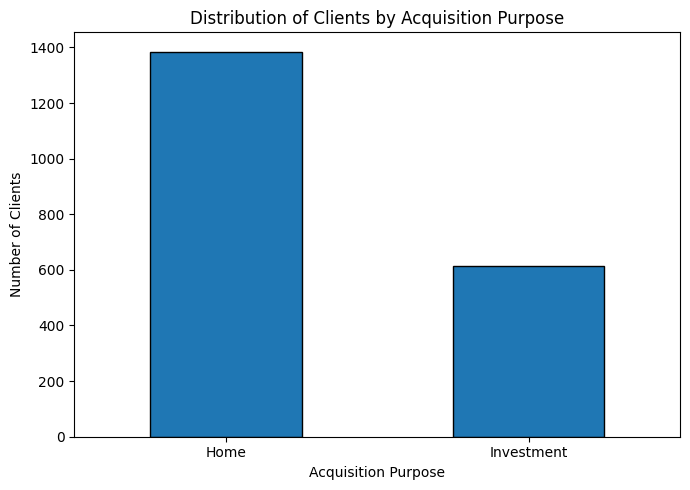

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

purpose_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Distribution of Clients by Acquisition Purpose')
plt.xlabel('Acquisition Purpose')
plt.ylabel('Number of Clients')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

gender
M    1012
F     988
Name: count, dtype: int64


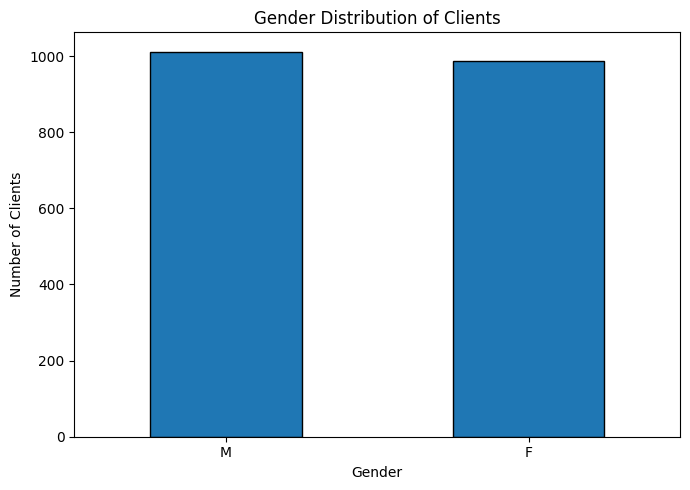

In [101]:
# EDA 7.2: Gender Distribution

gender_counts = clients['gender'].value_counts()

print(gender_counts)

plt.figure(figsize=(7,5))

gender_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Gender Distribution of Clients')
plt.xlabel('Gender')
plt.ylabel('Number of Clients')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

loan_applied
No     1264
Yes     736
Name: count, dtype: int64


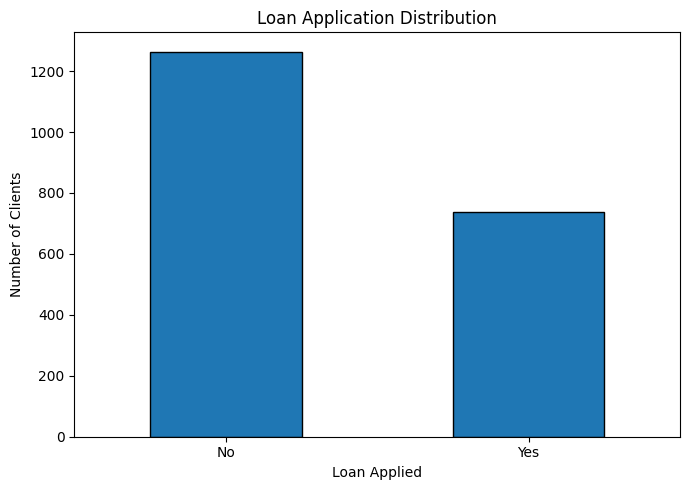

In [102]:
# EDA 7.3: Loan Application Distribution

loan_counts = clients['loan_applied'].value_counts()

print(loan_counts)

plt.figure(figsize=(7,5))

loan_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Loan Application Distribution')
plt.xlabel('Loan Applied')
plt.ylabel('Number of Clients')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

satisfaction_score
1    395
2    379
3    404
4    417
5    405
Name: count, dtype: int64


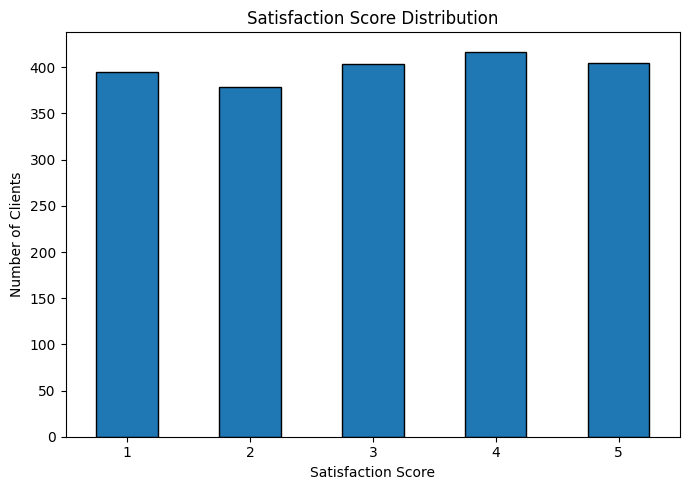

In [103]:
# EDA 7.4: Satisfaction Score Distirbution

satisfaction_counts = clients['satisfaction_score'].value_counts().sort_index()

print(satisfaction_counts)

plt.figure(figsize=(7,5))

satisfaction_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Satisfaction Score Distribution')
plt.xlabel('Satisfaction Score')
plt.ylabel('Number of Clients')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

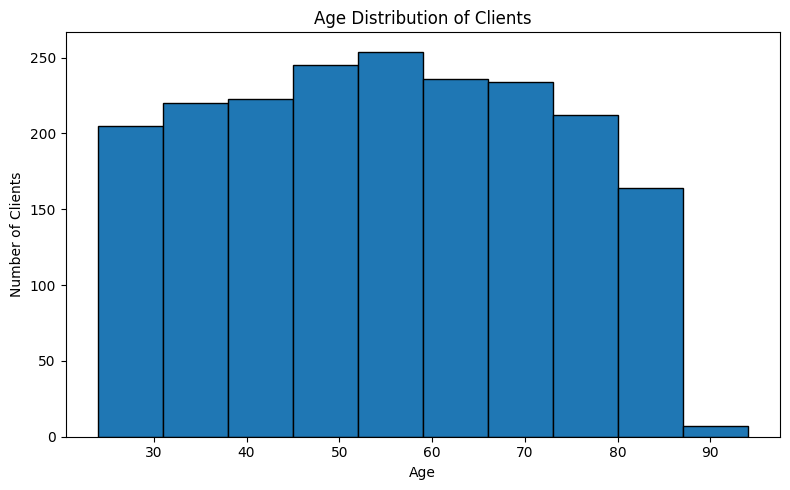

In [104]:
# EDA 7.5: Age Distribution

plt.figure(figsize=(8,5))

clients['age'].plot(
    kind='hist',
    bins=10,
    edgecolor='black'
)

plt.title('Age Distribution of Clients')
plt.xlabel('Age')
plt.ylabel('Number of Clients')
plt.tight_layout()

plt.show()

In [105]:
# EDA 7.6: Properties Dataset Overview

print("PROPERTIES DATASET OVERVIEW")
print("="*50)

print("Total Properties:", len(properties))
print("Total Features:", properties.shape[1])

print("\nListing Status:")
print(properties['listing_status'].value_counts())

print("\nUnit Category:")
print(properties['unit_category'].value_counts())

print("\nTower Number:")
print(properties['tower_number'].value_counts().sort_index())

print("\nSale Price Statistics:")
print(properties['sale_price'].describe())

print("\nFloor Area Statistics:")
print(properties['floor_area_sqft'].describe())


PROPERTIES DATASET OVERVIEW
Total Properties: 10000
Total Features: 9

Listing Status:
listing_status
Sold         7305
Available    2695
Name: count, dtype: int64

Unit Category:
unit_category
Apartment    8547
Office       1453
Name: count, dtype: int64

Tower Number:
tower_number
1     476
2     551
3     574
4     485
5     502
6     476
7     520
8     502
9     537
10    432
11    563
12    416
13    606
14    476
15    520
16    390
17    450
18    589
19    433
20    502
Name: count, dtype: int64

Sale Price Statistics:
count     10000.000000
mean     344374.678683
std      131563.099417
min       97402.800000
25%      232173.642500
50%      330680.845000
75%      448852.575000
max      736652.270000
Name: sale_price, dtype: float64

Floor Area Statistics:
count    10000.000000
mean      1139.941412
std        418.373967
min        410.710000
25%        782.200000
50%       1110.880000
75%       1499.000000
max       1957.160000
Name: floor_area_sqft, dtype: float64


listing_status
Sold         7305
Available    2695
Name: count, dtype: int64


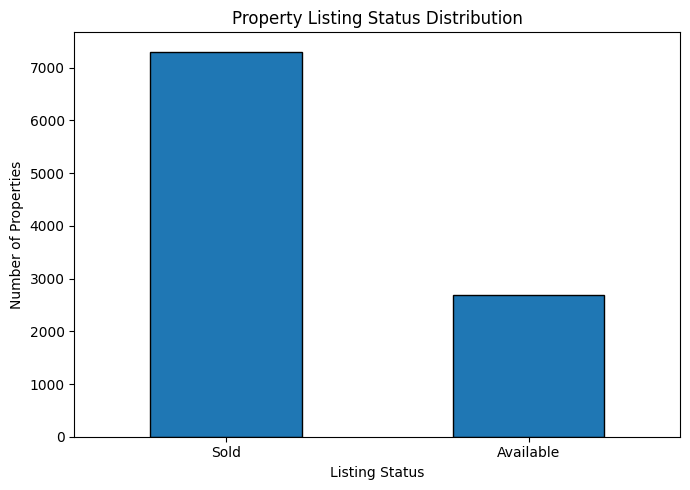

In [106]:
# EDA 7.6: Listing Status Distribution

status_counts = properties['listing_status'].value_counts()

print(status_counts)

plt.figure(figsize=(7,5))

status_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Property Listing Status Distribution')
plt.xlabel('Listing Status')
plt.ylabel('Number of Properties')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

unit_category
Apartment    8547
Office       1453
Name: count, dtype: int64


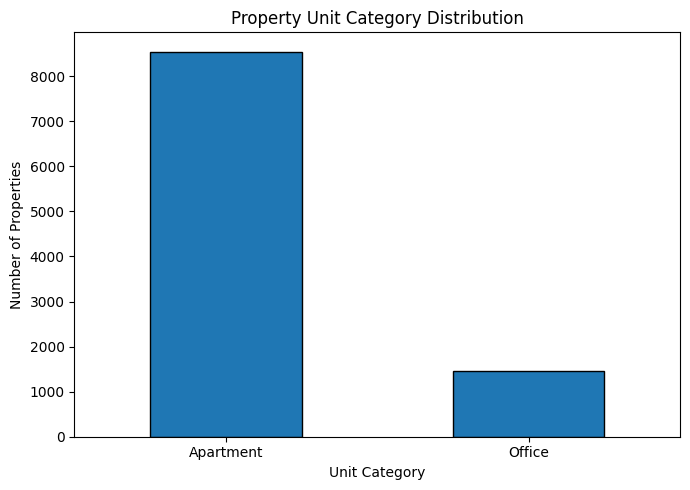

In [107]:
# EDA 7.7: Unit Category Distribution

category_counts = properties['unit_category'].value_counts()

print(category_counts)

plt.figure(figsize=(7,5))

category_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Property Unit Category Distribution')
plt.xlabel('Unit Category')
plt.ylabel('Number of Properties')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()


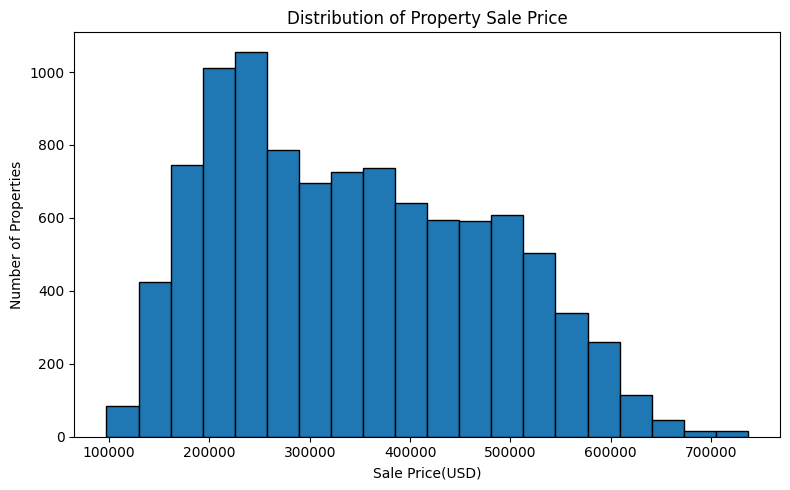

In [108]:
# EDA 7.8: Sale Price Distribution

plt.figure(figsize=(8,5))

plt.hist(
    properties['sale_price'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Property Sale Price')
plt.xlabel('Sale Price(USD)')
plt.ylabel('Number of Properties')
plt.tight_layout()

plt.show()

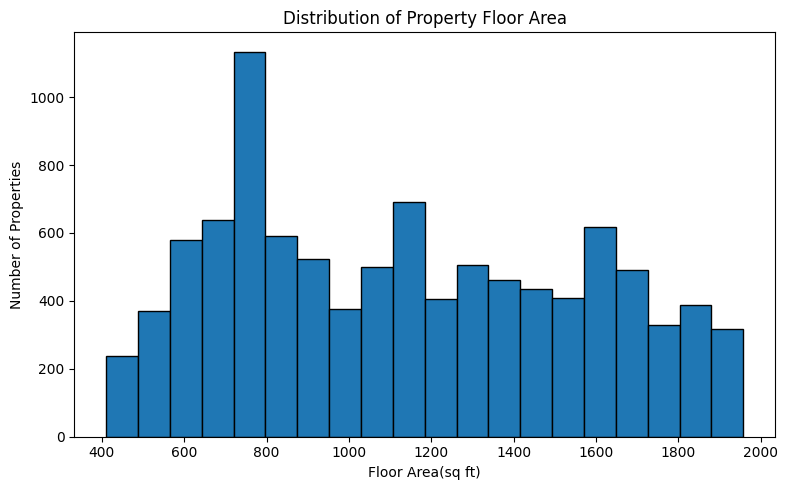

In [109]:
# EDA 7.9: Floor Area Distribution

plt.figure(figsize=(8,5))

plt.hist(
    properties['floor_area_sqft'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Property Floor Area')
plt.xlabel('Floor Area(sq ft)')
plt.ylabel('Number of Properties')
plt.tight_layout()

plt.show()


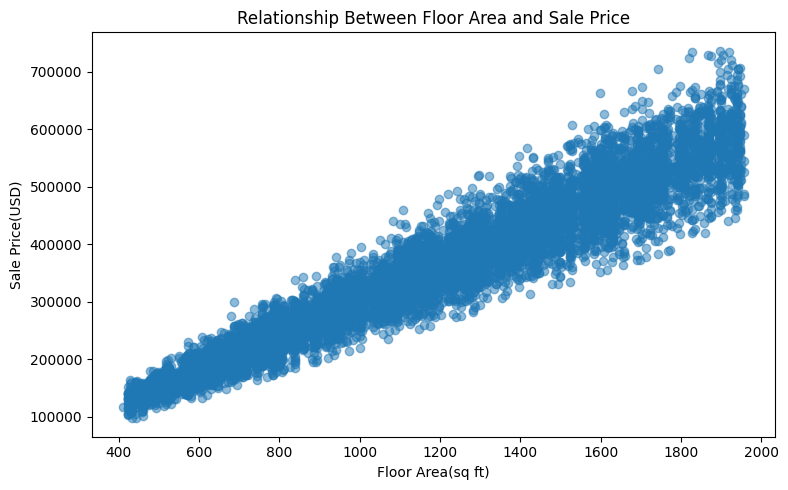

In [110]:
# EDA 7.10: Floor Area vs Sale Price

plt.figure(figsize=(8,5))

plt.scatter(
    properties['floor_area_sqft'],
    properties['sale_price'],
    alpha=0.5,
)

plt.title('Relationship Between Floor Area and Sale Price')
plt.xlabel('Floor Area(sq ft)')
plt.ylabel('Sale Price(USD)')
plt.tight_layout()

plt.show()


In [111]:
# EDA 7.11: Correlation between Floor Area and Sale Price

correlation = properties['floor_area_sqft'].corr(properties['sale_price'])

print("Correlation between Floor Area and Sale Price:",)
print(round(correlation,4))

Correlation between Floor Area and Sale Price:
0.9603


Average Sale Price by Unit Category:
unit_category
Office       362465.219601
Apartment    341299.265561
Name: sale_price, dtype: float64


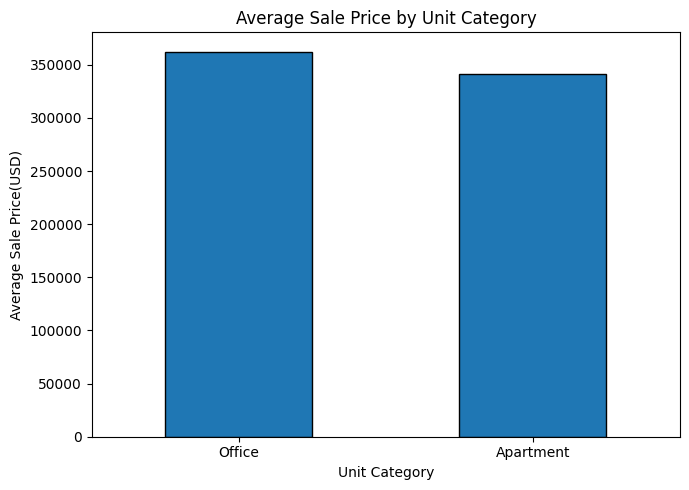

In [112]:
# EDA 7.12: Average Sale Price by Unit Category

avg_price_by_category = (properties.groupby('unit_category')
['sale_price']
      .mean()
      .sort_values(ascending=False)
)

print("Average Sale Price by Unit Category:")

print(avg_price_by_category)

plt.figure(figsize=(7,5))

avg_price_by_category.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Sale Price by Unit Category')
plt.xlabel('Unit Category')
plt.ylabel('Average Sale Price(USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Sale Price by Listing Status:
listing_status
Sold         345072.000115
Available    342484.536545
Name: sale_price, dtype: float64


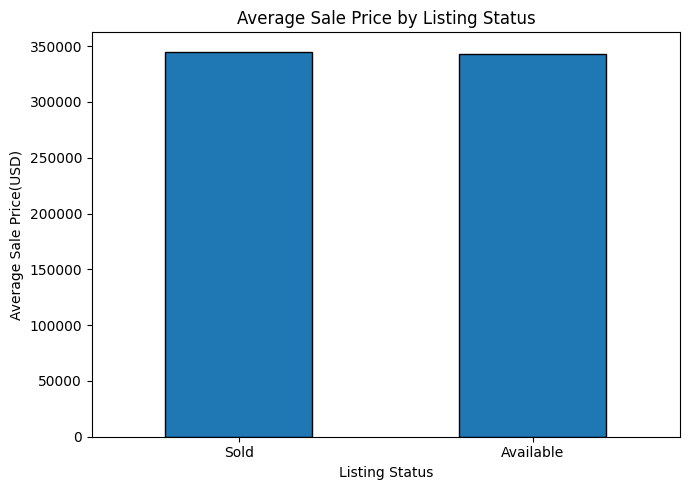

In [113]:
# EDA 7.13: Average Sale Price by Listing Status

avg_price_by_status = (
properties.groupby('listing_status')
['sale_price']
      .mean()
      .sort_values(ascending=False)
)

print("Average Sale Price by Listing Status:")

print(avg_price_by_status)

plt.figure(figsize=(7,5))

avg_price_by_status.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Sale Price by Listing Status')
plt.xlabel('Listing Status')
plt.ylabel('Average Sale Price(USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Properties by Tower:
tower_number
1     476
2     551
3     574
4     485
5     502
6     476
7     520
8     502
9     537
10    432
11    563
12    416
13    606
14    476
15    520
16    390
17    450
18    589
19    433
20    502
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

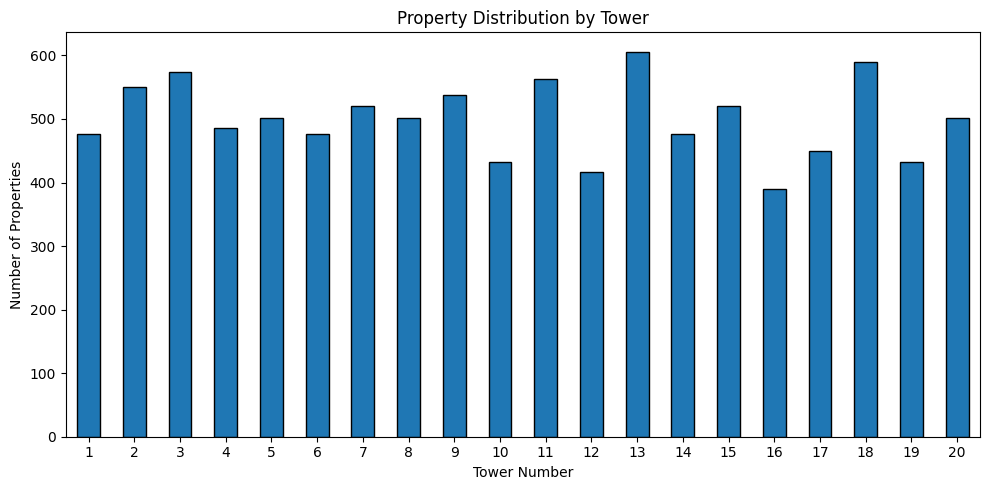

In [114]:
# EDA 7.14: Tower-wise Property Distribution

tower_counts = properties['tower_number'].value_counts().sort_index()

print("Properties by Tower:")
print(tower_counts)

plt.figure(figsize=(10,5))

tower_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Property Distribution by Tower')
plt.xlabel('Tower Number')
plt.ylabel('Number of Properties')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show

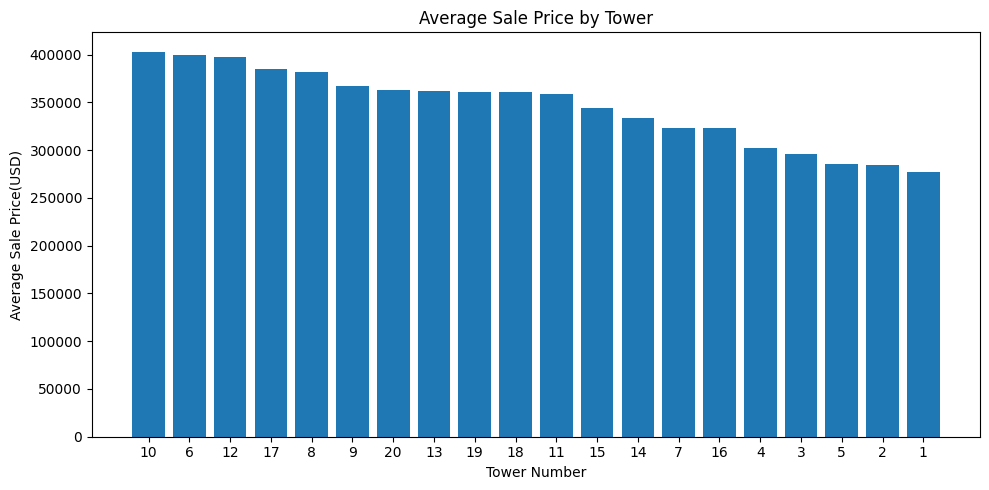

In [115]:
# EDA 7.15: Average Sale Price by Tower

avg_price_by_tower = properties.groupby('tower_number')['sale_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

plt.bar(
    avg_price_by_tower.index.astype(str),
    avg_price_by_tower.values,
)

plt.title('Average Sale Price by Tower')
plt.xlabel('Tower Number')
plt.ylabel('Average Sale Price(USD)')

plt.tight_layout()
plt.show()

In [116]:
print(properties.columns.tolist())

['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']


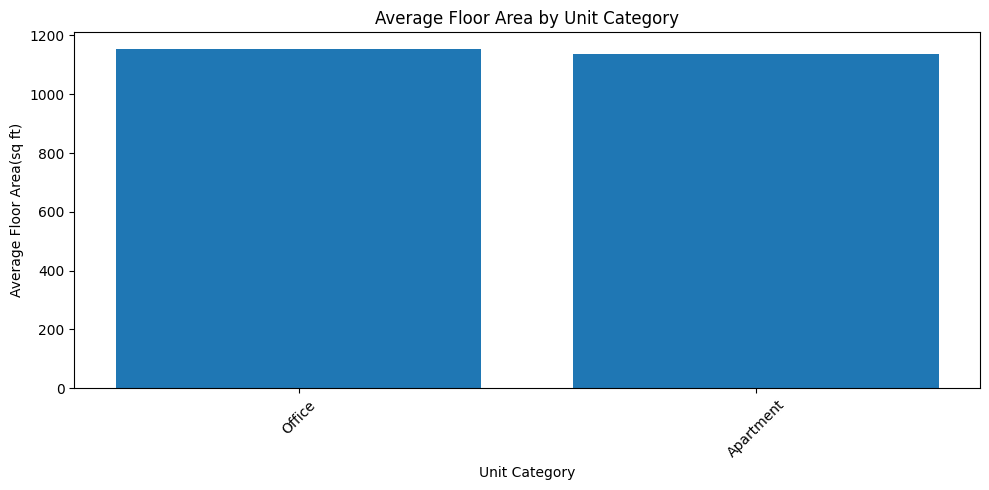

In [117]:
# EDA 7.16: Average Floor Area by Units Category

avg_area_category = (

properties.groupby('unit_category')
['floor_area_sqft']
     .mean().sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(

avg_area_category.index.astype(str),
    avg_area_category.values,
)

plt.title('Average Floor Area by Unit Category')
plt.xlabel('Unit Category')
plt.ylabel('Average Floor Area(sq ft)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average Sale Price by Listing Status:
listing_status
Available    342484.536545
Sold         345072.000115
Name: sale_price, dtype: float64


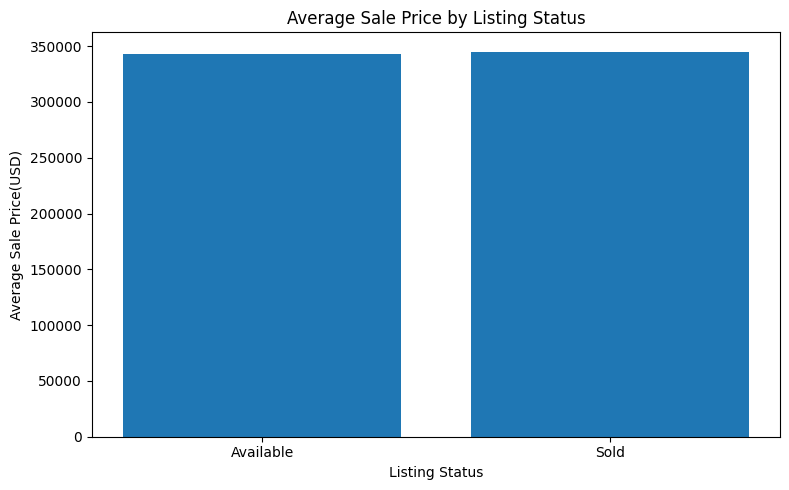

In [118]:
# EDA 7.17: Average Sale Price by Listing Status

avg_price_by_status = properties.groupby('listing_status')['sale_price'].mean()


print("Average Sale Price by Listing Status:")
print(avg_price_by_status)

plt.figure(figsize=(8,5))

plt.bar(avg_price_by_status.index,
avg_price_by_status.values)

plt.title('Average Sale Price by Listing Status')
plt.xlabel('Listing Status')
plt.ylabel('Average Sale Price(USD)')

plt.tight_layout()
plt.show()

In [119]:
# Check actual columns in properties dataset

print("Properties columns:")
print(properties.columns.tolist())


Properties columns:
['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']


Average Sale Price by Transaction Date:
transaction_date
2024-01-01    344147.603705
2024-02-01    340676.274922
2024-03-01    344501.554094
2024-04-01    346109.677375
2024-05-01    344503.668063
2024-06-01    349011.054916
2024-07-01    337710.297756
2024-08-01    342208.598646
2024-09-01    341476.329516
2024-10-01    341916.365612
2024-11-01    347307.021883
2024-12-01    347892.844205
2025-01-01    344978.723528
2025-02-01    327079.052861
2025-03-01    347295.628469
2025-04-01    357384.025452
2025-05-01    337301.612625
2025-06-01    350230.843692
2025-07-01    343410.764185
2025-08-01    347252.602663
2025-09-01    353187.866719
2025-10-01    338316.300029
2025-11-01    351677.376101
2025-12-01    342873.121798
Name: sale_price, dtype: float64


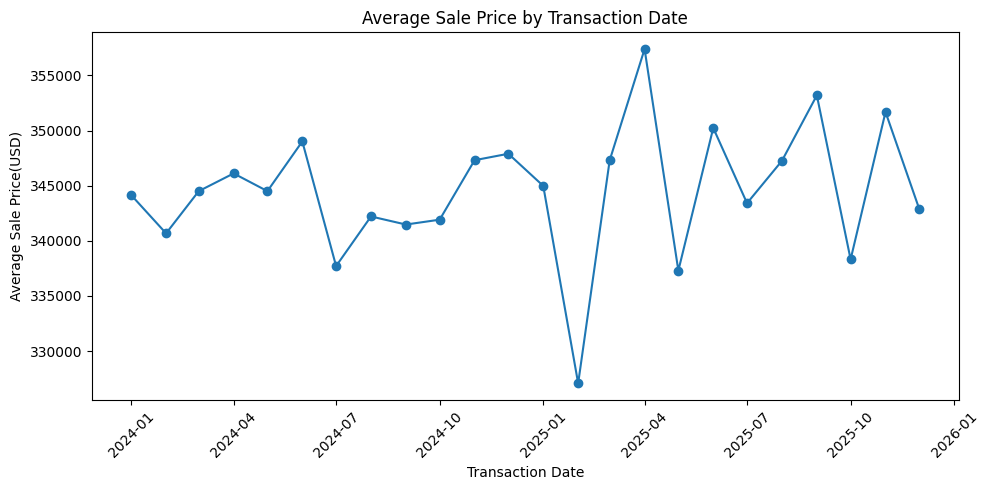

In [120]:

# EDA 7.18: Average Sale Price by Transaction Date

properties['transaction_date'] = pd.to_datetime(properties['transaction_date'])

avg_price_by_date = (
    properties.groupby('transaction_date')['sale_price']
    .mean()
    .sort_index()
)

print("Average Sale Price by Transaction Date:")
print(avg_price_by_date)

plt.figure(figsize=(10,5))

plt.plot(
    avg_price_by_date.index,
    avg_price_by_date.values,
    marker='o'
)

plt.title('Average Sale Price by Transaction Date')
plt.xlabel('Transaction Date')
plt.ylabel('Average Sale Price(USD)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1388/2030057464.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Average Sale Price by Floor Area Range:
floor_area_sqft
0-500        139258.603833
501-1000     228018.884711
1001-1500    375979.830100
1501-2000    517673.442662
2001+                  NaN
Name: sale_price, dtype: float64


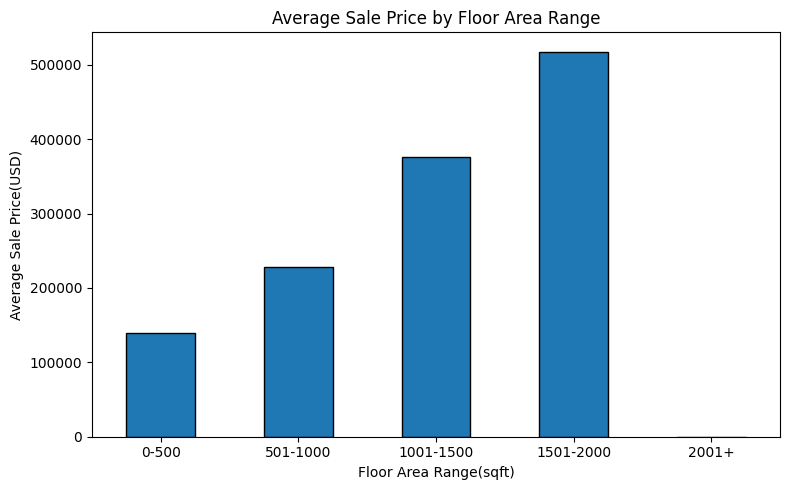

In [121]:
# EDA 7.19: Average Sale Price by Floor Area Range

properties['floor_area_sqft'] = pd.cut(
    properties['floor_area_sqft'],
    bins=[0, 500, 1000, 1500, 2000, float('inf')],
    labels=['0-500', '501-1000', '1001-1500', '1501-2000', '2001+']
)

avg_price_by_area = (
    properties.groupby('floor_area_sqft')['sale_price']
    .mean()
)

print("Average Sale Price by Floor Area Range:")
print(avg_price_by_area)

plt.figure(figsize=(8,5))

avg_price_by_area.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Sale Price by Floor Area Range')
plt.xlabel('Floor Area Range(sqft)')
plt.ylabel('Average Sale Price(USD)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Floor Area by Listing Status:
listing_status
Available   NaN
Sold        NaN
Name: floor_area_sqft, dtype: float64


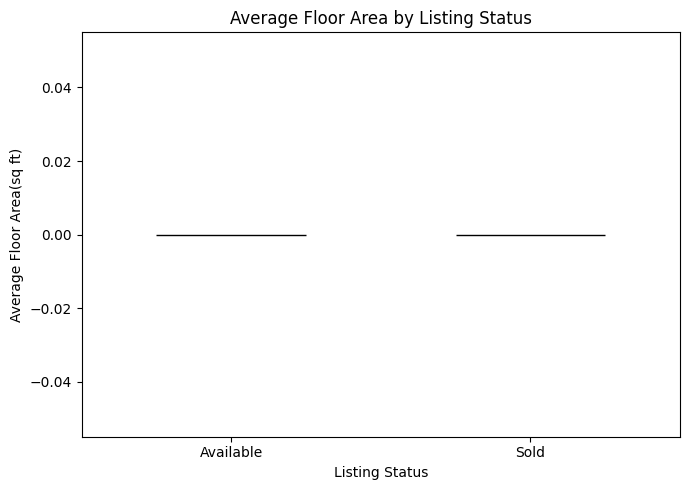

In [122]:
# EDA 7.20: Average Floor Area by Listing Status

# Convert floor area back ti numeric
properties['floor_area_sqft'] = pd.to_numeric(
    properties['floor_area_sqft'],
    errors='coerce')

avg_area_by_status = (

properties.groupby('listing_status')
['floor_area_sqft']
    .mean()
    .sort_values(ascending=False)
)

print("Average Floor Area by Listing Status:")
print(avg_area_by_status)

plt.figure(figsize=(7,5))

avg_area_by_status.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Floor Area by Listing Status')
plt.xlabel('Listing Status')
plt.ylabel('Average Floor Area(sq ft)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [123]:
print(properties['floor_area_sqft'].dtype)
print(properties['floor_area_sqft'].head(10))

float64
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: floor_area_sqft, dtype: float64


In [124]:
# Restore the original properties dataset

properties = pd.read_csv('/content/properties.csv')

properties['transaction_date'] = pd.to_datetime(
    properties['transaction_date']
)

print(properties.columns.tolist())
print(properties['floor_area_sqft'].head())


['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']
0    1160.36
1     782.25
2     756.21
3     743.09
4     701.66
Name: floor_area_sqft, dtype: float64


Number of Properties by Unit Category:
unit_category
Apartment    8547
Office       1453
Name: count, dtype: int64


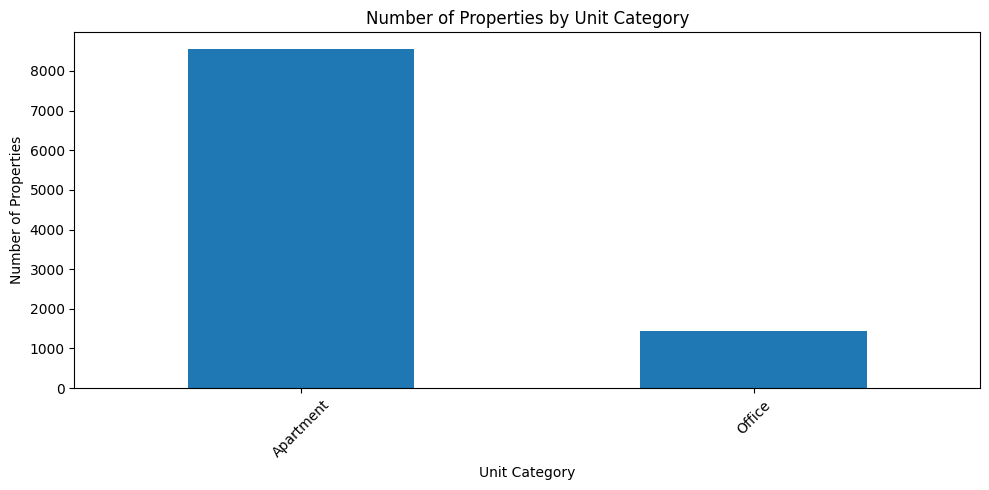

In [125]:
# EDA 7.21: Number of Properties by Unit Category

unit_category_counts = properties['unit_category'].value_counts()

print("Number of Properties by Unit Category:")
print(unit_category_counts)

plt.figure(figsize=(10,5))

unit_category_counts.plot(kind='bar')

plt.title('Number of Properties by Unit Category')
plt.xlabel('Unit Category')
plt.ylabel('Number of Properties')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [126]:
print(properties.columns.tolist())

['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']


Number of Properties by Listing Status:
listing_status
Sold         7305
Available    2695
Name: count, dtype: int64


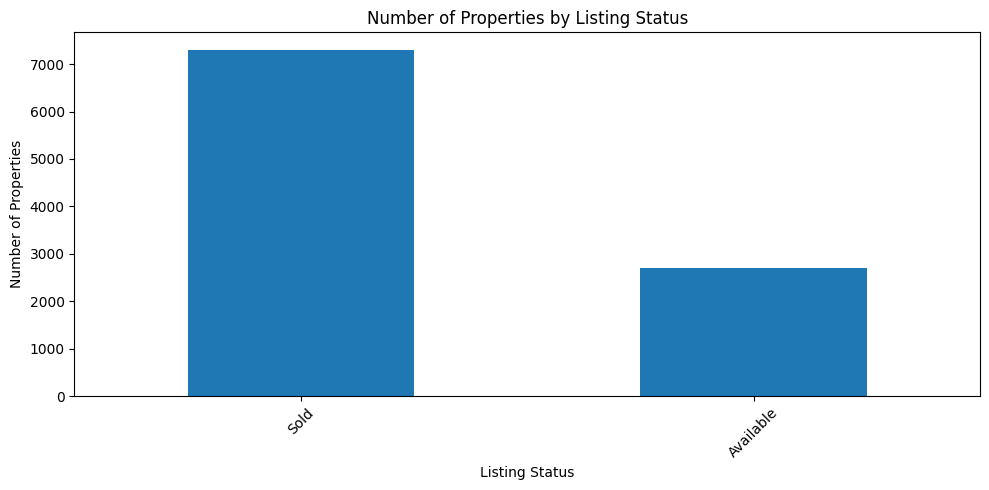

In [127]:
# EDA 7.22: Number of Properties by Listing Status

listing_status_counts = properties['listing_status'].value_counts()

print("Number of Properties by Listing Status:")
print(listing_status_counts)

plt.figure(figsize=(10,5))

listing_status_counts.plot(kind='bar')

plt.title('Number of Properties by Listing Status')
plt.xlabel('Listing Status')
plt.ylabel('Number of Properties')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

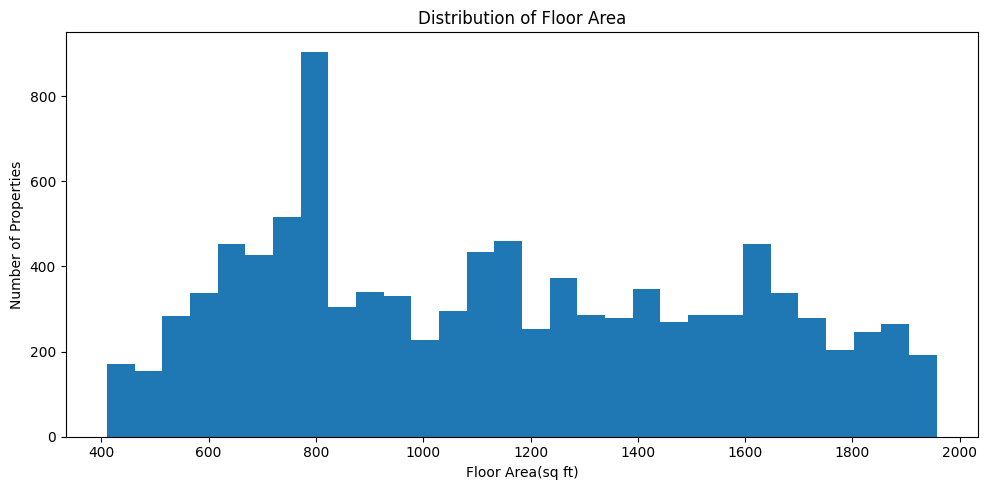

In [128]:
# EDA 7.23: Distribution of floor Area

plt.figure(figsize=(10,5))

plt.hist(properties['floor_area_sqft'],bins=30)

plt.title('Distribution of Floor Area')
plt.xlabel('Floor Area(sq ft)')
plt.ylabel('Number of Properties')

plt.tight_layout()
plt.show()

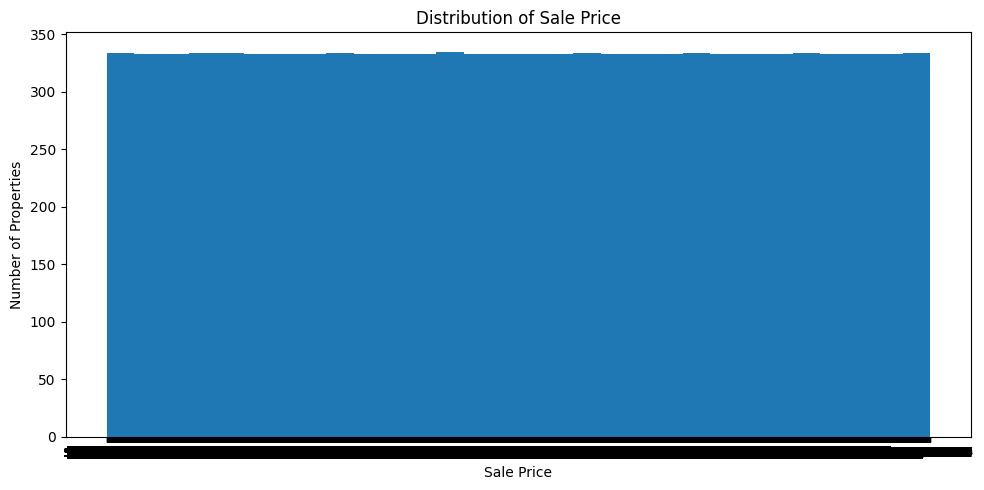

In [129]:
# EDA 7.24: Distribution of Sale Price

plt.figure(figsize=(10,5))

plt.hist(properties['sale_price'],bins=30)

plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Number of Properties')

plt.tight_layout()
plt.show()

Client Type Distribution:
client_type
Individual    1897
Company        103
Name: count, dtype: int64


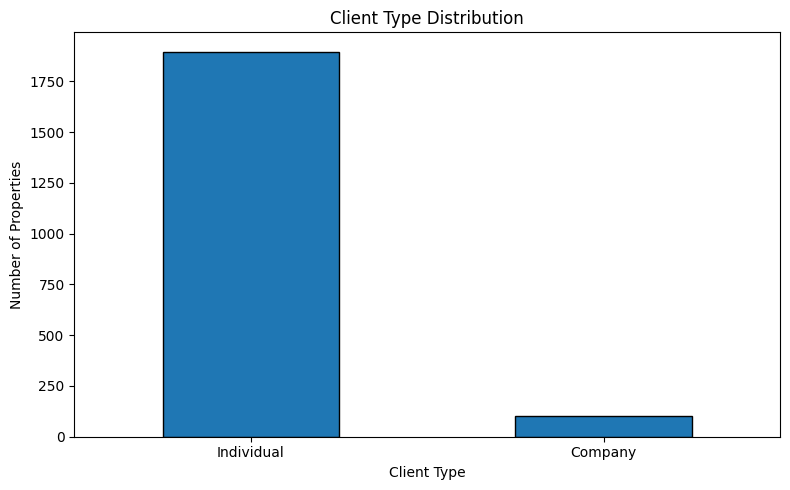

In [130]:
# EDA 7.25: Client Type Distribution

client_type_counts = clients['client_type'].value_counts()

print("Client Type Distribution:")
print(client_type_counts)

plt.figure(figsize=(8,5))

client_type_counts.plot(
    kind='bar',
    edgecolor='black'
    )

plt.title('Client Type Distribution')
plt.xlabel('Client Type')
plt.ylabel('Number of Properties')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Number of Clients by Country:
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64


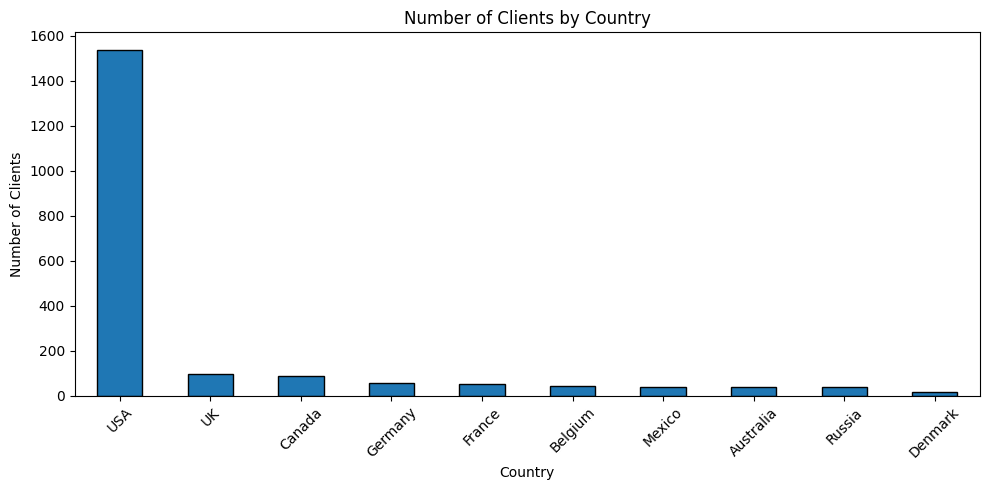

In [131]:
import matplotlib.pyplot as plt

country_counts = clients['country'].value_counts()

print("Number of Clients by Country:")
print(country_counts)

plt.figure(figsize=(10,5))

country_counts.plot( kind='bar',
edgecolor='black')

plt.title('Number of Clients by Country')
plt.xlabel('Country')
plt.ylabel('Number of Clients')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Number of Client by Region:
region
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Ohio                       24
Northern Ireland           24
British Columbia           20
Wales                      17
Brittany                   16
Flanders                   16
Hamburg                    16
Ile-de-France              15
Manitoba                   15
Wallonia                   15
Quebec                     14
Victoria                   13
New South Wales            13
Brussels                   12
Bavaria                    12
Berlin                     11
Krasnodar Krai             10
North

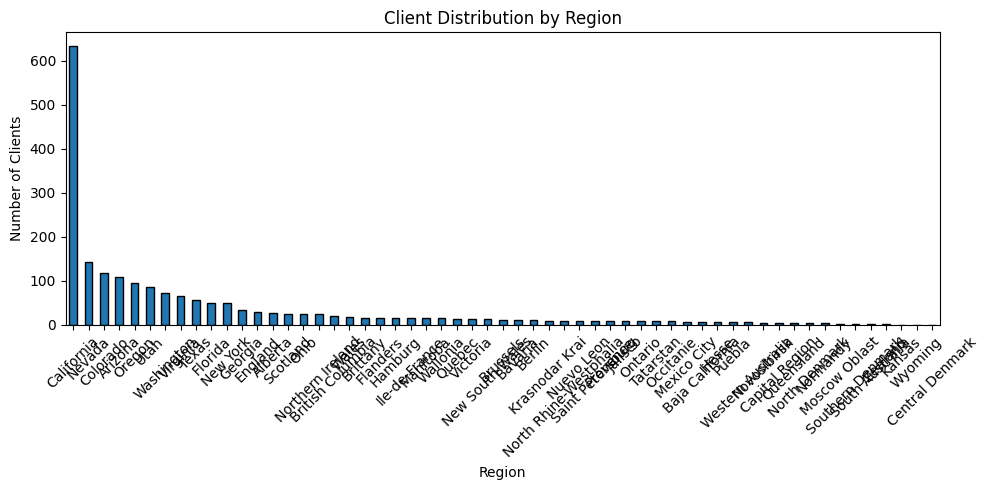

In [132]:
# EDA 7.27: Client Distribution by Region

print("Number of Client by Region:")
print(clients['region'].value_counts())

plt.figure(figsize=(10,5))

clients['region'].value_counts().plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Client Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Clients')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Number of Client by Acquisition Purpose:
acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64


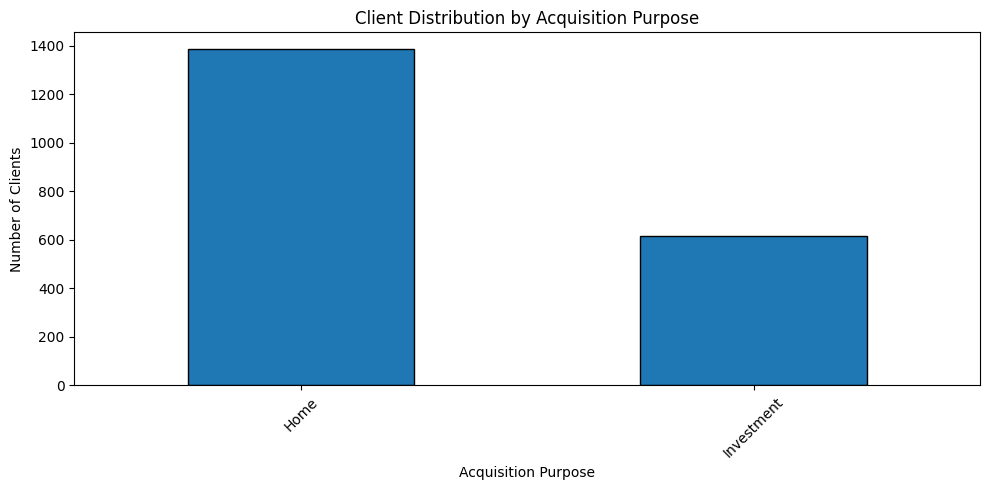

In [133]:
# EDA 7.28: Client Acquisition Purpose Distribution

print("Number of Client by Acquisition Purpose:")
print(purpose_counts)

plt.figure(figsize=(10,5))

purpose_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Client Distribution by Acquisition Purpose')
plt.xlabel('Acquisition Purpose')
plt.ylabel('Number of Clients')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Number of Clients by Client Type:
client_type
Individual    1897
Company        103
Name: count, dtype: int64


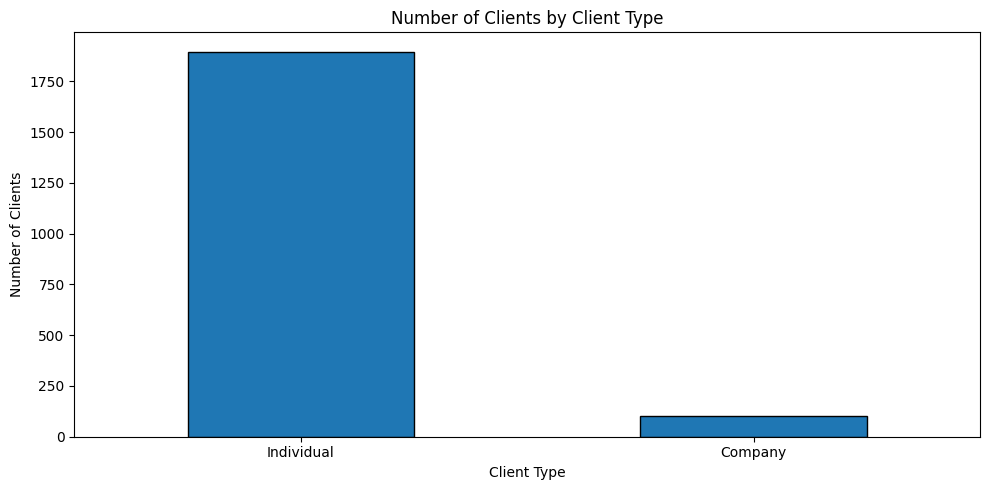

In [134]:
# EDA 7.29: Number of Clients by Client Type

client_type_counts = clients['client_type'].value_counts()

print("Number of Clients by Client Type:")
print(client_type_counts)

plt.figure(figsize=(10,5))

client_type_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Number of Clients by Client Type')
plt.xlabel('Client Type')
plt.ylabel('Number of Clients')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Feature Encoding

In [135]:
print(clients.columns.tolist())

['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'date_of_birth_clear', 'age']


Number of Clients by Country:
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64


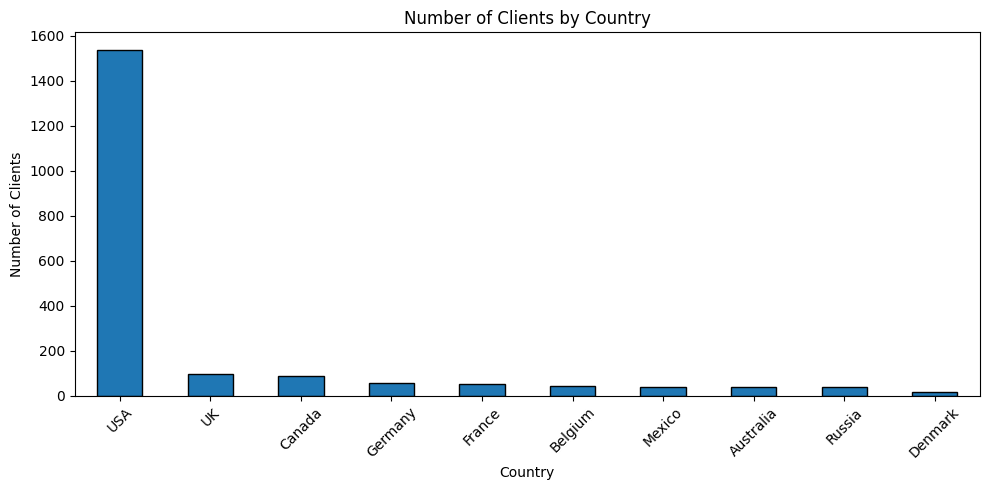

In [136]:
country_counts = clients['country'].value_counts()

print("Number of Clients by Country:")
print(country_counts)

plt.figure(figsize=(10,5))

country_counts.plot( kind='bar',
edgecolor='black')

plt.title('Number of Clients by Country')
plt.xlabel('Country')
plt.ylabel('Number of Clients')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [137]:
# Select features directly from clients dataset

ml_data = clients[
    [
        'client_type',
        'gender',
        'country',
        'region',
        'acquisition_purpose',
        'loan_applied',
        'referral_channel',
        'age',
        'satisfaction_score'
    ]
].copy()

# Categorical columns to encode
categorical_columns = [
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]

# One-Hot Encoding
encoded_data = pd.get_dummies(
    ml_data,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

print("Original data shape:",
      ml_data.shape)
print("Encoded data shape:",
      encoded_data.shape)

print("\nEncode data:")
display(encoded_data.head())

Original data shape: (2000, 9)
Encoded data shape: (2000, 80)

Encode data:


,age,satisfaction_score,client_type_Company,client_type_Individual,gender_F,gender_M,country_Australia,country_Belgium,country_Canada,country_Denmark,...,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website
0,57,4,0,1,1,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1
1,62,1,0,1,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
2,66,4,0,1,0,1,0,0,0,0,...,0,0,0,1,0,0,1,1,0,0
3,65,5,0,1,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
4,49,5,1,0,0,1,0,0,0,0,...,0,0,0,0,1,1,0,0,0,1


## 9. Feature Scaling

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(encoded_data)

scaled_data = pd.DataFrame(
    scaled_data,
    columns=encoded_data.columns,
    index=encoded_data.index
)

print("Scaled data shape:",
scaled_data.shape)

display(scaled_data.head())

Scaled data shape: (2000, 80)


,age,satisfaction_score,client_type_Company,client_type_Individual,gender_F,gender_M,country_Australia,country_Belgium,country_Canada,country_Denmark,...,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website
0,0.138300,0.687089,-0.233016,0.233016,1.012073,-1.012073,-0.141024,-0.148231,-0.210681,-0.086929,...,-0.054855,-0.022366,-0.031639,0.666366,-0.666366,-1.310493,1.310493,-0.737836,-0.325875,0.901796
1,0.426485,-1.435740,-0.233016,0.233016,-0.988071,0.988071,-0.141024,-0.148231,-0.210681,-0.086929,...,-0.054855,-0.022366,-0.031639,0.666366,-0.666366,0.763072,-0.763072,-0.737836,-0.325875,0.901796
2,0.657033,0.687089,-0.233016,0.233016,-0.988071,0.988071,-0.141024,-0.148231,-0.210681,-0.086929,...,-0.054855,-0.022366,-0.031639,0.666366,-0.666366,-1.310493,1.310493,1.355315,-0.325875,-1.108898
3,0.599396,1.394698,-0.233016,0.233016,-0.988071,0.988071,-0.141024,-0.148231,-0.210681,-0.086929,...,-0.054855,-0.022366,-0.031639,0.666366,-0.666366,0.763072,-0.763072,-0.737836,-0.325875,0.901796
4,-0.322796,1.394698,4.291559,-4.291559,-0.988071,0.988071,-0.141024,-0.148231,-0.210681,-0.086929,...,-0.054855,-0.022366,-0.031639,-1.500677,1.500677,0.763072,-0.763072,-0.737836,-0.325875,0.901796


## 10. K-Means Clustering

K value: range(2, 11)
Inertia values: [155592.86299361792, 153480.35990059018, 149657.4663840333, 147328.75542900426, 143072.39782979965, 142440.9817081476, 140017.58503585923, 136379.88045082532, 133738.83169254343]


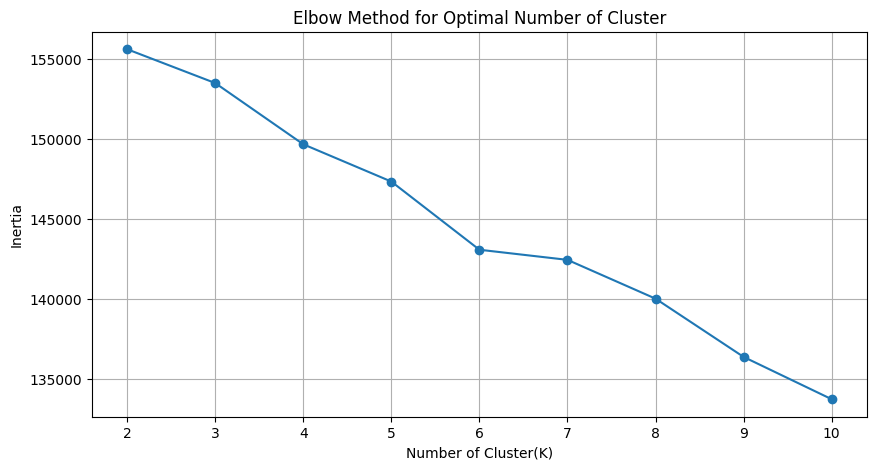

In [139]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = range(2,11)
inertia_values = []

for k in k_values:
    inertia_values.append(
        KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled_data).inertia_
)

print("K value:", k_values)
print("Inertia values:", inertia_values)

plt.figure(figsize=(10,5))

plt.plot(k_values, inertia_values, marker='o')

plt.title('Elbow Method for Optimal Number of Cluster')
plt.xlabel('Number of Cluster(K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

## Silhouette Score

Silhouette Scores:
K = 2: 0.2187
K = 3: 0.0881
K = 4: 0.0583
K = 5: 0.0821
K = 6: 0.0439
K = 7: 0.0692
K = 8: -0.0296
K = 9: 0.0902
K = 10: 0.0945


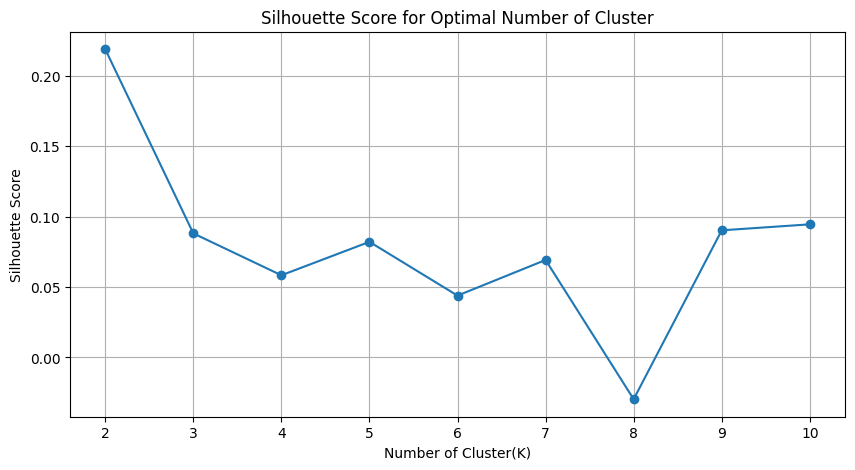

In [140]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_labels = km.fit_predict(scaled_data)

    score = silhouette_score(scaled_data, cluster_labels)

    silhouette_scores.append(score)

print("Silhouette Scores:")

for k, score in zip(range(2,11), silhouette_scores):
    print(f"K = {k}: {score:.4f}")

plt.figure(figsize=(10,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score for Optimal Number of Cluster')
plt.xlabel('Number of Cluster(K)')
plt.ylabel('Silhouette Score')

plt.xticks(range(2,11))
plt.grid(True)
plt.show()

In [141]:
from sklearn.cluster import KMeans

# Final K-Means model
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Assign cluster labels
clients['cluster'] = final_kmeans.fit_predict(scaled_data)

print("K-Means clustering completed successfully.")

print("\nCluster Distribution:")
print(clients['cluster'].value_counts().sort_index())

K-Means clustering completed successfully.

Cluster Distribution:
cluster
0     15
1    940
2    942
3    103
Name: count, dtype: int64


## Cluster Interpretation

In [142]:
# Check cluster labels
print("Cluster column values:")
print(clients['cluster'].value_counts().sort_index())

# Create cluster profile
cluster_profile = clients.groupby('cluster').agg(
    customer_count=('client_id', 'count'),
    average_age=('age', 'mean'),
    average_satisfaction=('satisfaction_score', 'mean')
).round(2)

print("\nCluster Profile:")
print(cluster_profile)

Cluster column values:
cluster
0     15
1    940
2    942
3    103
Name: count, dtype: int64

Cluster Profile:
         customer_count  average_age  average_satisfaction
cluster                                                   
0                    15        50.27                  3.27
1                   940        54.71                  3.03
2                   942        55.43                  3.02
3                   103        46.66                  3.07


## Categorical cluster profile

In [143]:
# Cluster-wise categorical profile

categorical_features = [
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]

for col in categorical_features:
    print("\n" + "=" * 60)
    print(f"Cluster Distribution by {col}")
    print("=" * 60)

    profile = pd.crosstab(
        clients['cluster'],
        clients[col],
        normalize='index'
    )

    display(profile)


Cluster Distribution by client_type


client_type,Company,Individual
cluster,,
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,1.0,0.0



Cluster Distribution by gender


gender,F,M
cluster,,
0,0.533333,0.466667
1,1.000000,0.000000
2,0.000000,1.000000
3,0.388350,0.611650



Cluster Distribution by country


...

acquisition_purpose,Home,Investment
cluster,,
0,0.666667,0.333333
1,0.698936,0.301064
2,0.691083,0.308917
3,0.650485,0.349515



Cluster Distribution by loan_applied


loan_applied,No,Yes
cluster,,
0,0.666667,0.333333
1,0.638298,0.361702
2,0.630573,0.369427
3,0.582524,0.417476



Cluster Distribution by referral_channel


referral_channel,Agency,Client,Website
cluster,,,
0,0.266667,0.200000,0.533333
1,0.345745,0.093617,0.560638
2,0.358811,0.094480,0.546709
3,0.368932,0.116505,0.514563


In [144]:
# Find the dominent country and region for each cluster

print("Dominant Country by Cluster:")
dominent_country = clients.groupby('cluster')['country'].agg(
    lambda x: x.value_counts().index[0]
)
print(dominent_country)

print("\nDominant Region by Cluster:")
dominent_region = clients.groupby('cluster')['region'].agg(
    lambda x: x.value_counts().index[0]
)
print(dominent_region)


Dominant Country by Cluster:
cluster
0    Canada
1       USA
2       USA
3       USA
Name: country, dtype: object

Dominant Region by Cluster:
cluster
0      Manitoba
1    California
2    California
3    California
Name: region, dtype: object


### Cluster-wise investment & loan counts

In [145]:
# Detailed cluster behavior

for cluster in sorted(clients['cluster'].unique()):

    data = clients[clients['cluster'] == cluster]

customer = len(data)
investment = (data['acquisition_purpose'] == 'Investment').sum()
home = (data['acquisition_purpose'] == 'Home').sum()
loans = (data['loan_applied'] == 'Yes').sum()
avg_age = data['age'].mean()
avg_satisfaction = data['satisfaction_score'].mean()

print(f"\nCluster {cluster}:")
print("=" * 40)
print(f"Customer: {customer}")
print(f"Investment buyers: {investment}")
print(f"Home buyers: {home}")
print(f"Loans users: {loans}")
print(f"Average Age: {avg_age:.2f}")
print(f"Average Satisfaction Score: {avg_satisfaction:.2f}")


Cluster 3:
Customer: 103
Investment buyers: 36
Home buyers: 67
Loans users: 43
Average Age: 46.66
Average Satisfaction Score: 3.07


### Cluster 0

In [146]:
cluster_0 = clients[clients['cluster'] == 0]

print("Cluster 0")
print("=" * 40)
print("Customer:", len(cluster_0))
print("Investment buyers:", (cluster_0['acquisition_purpose'] == 'Investment').sum())
print("Home buyers:", (cluster_0['acquisition_purpose'] == 'Home').sum())
print("Loans users:", (cluster_0['loan_applied'] == 'Yes').sum())
print("Average Age:", round(cluster_0['age'].mean(), 2))
print("Average Satisfaction Score:", round(cluster_0['satisfaction_score'].mean(), 2))

Cluster 0
Customer: 15
Investment buyers: 5
Home buyers: 10
Loans users: 5
Average Age: 50.27
Average Satisfaction Score: 3.27


### Cluster 1

In [147]:
cluster_1 = clients[clients['cluster'] == 1]

print("Cluster 1")
print("=" * 40)
print("Customer:", len(cluster_1))
print("Investment buyers:", (cluster_1['acquisition_purpose'] == 'Investment').sum())
print("Home buyers:", (cluster_1['acquisition_purpose'] == 'Home').sum())
print("Loans users:", (cluster_1['loan_applied'] == 'Yes').sum())
print("Average Age:", round(cluster_1['age'].mean(), 2))
print("Average Satisfaction Score:", round(cluster_1['satisfaction_score'].mean(), 2))

Cluster 1
Customer: 940
Investment buyers: 283
Home buyers: 657
Loans users: 340
Average Age: 54.71
Average Satisfaction Score: 3.03


### Cluster 2

In [148]:
cluster_2 = clients[clients['cluster'] == 2]

print("Cluster 2")
print("=" * 40)
print("Customer:", len(cluster_2))
print("Investment buyers:", (cluster_2['acquisition_purpose'] == 'Investment').sum())
print("Home buyers:", (cluster_2['acquisition_purpose'] == 'Home').sum())
print("Loans users:", (cluster_2['loan_applied'] == 'Yes').sum())
print("Average Age:", round(cluster_2['age'].mean(), 2))
print("Average Satisfaction Score:", round(cluster_2['satisfaction_score'].mean(), 2))

Cluster 2
Customer: 942
Investment buyers: 291
Home buyers: 651
Loans users: 348
Average Age: 55.43
Average Satisfaction Score: 3.02


## Cluster Comparison Visualization

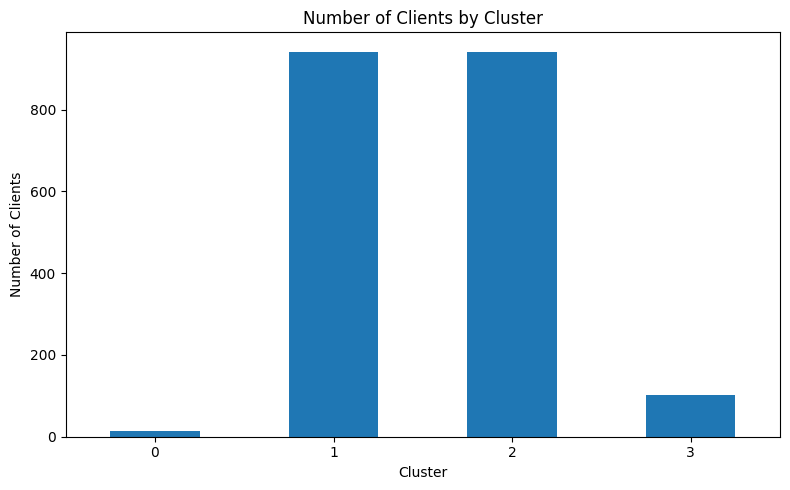

In [149]:
# Cluster comparison chart

cluster_counts = clients['cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))

cluster_counts.plot(kind='bar')

plt.title('Number of Clients by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Clients')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Hierarchical Clustering

In [150]:
from sklearn.metrics import silhouette_score

hierarchical_silhouette = silhouette_score(
    scaled_data,
    hierarchical_labels
)

print("Hierarchical Silhouette Score:", round(hierarchical_silhouette, 4))

print("\nHierarchical Cluster Distribution:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

Hierarchical Silhouette Score: 0.2804

Hierarchical Cluster Distribution:
0     282
1    1538
2      95
3      85
Name: count, dtype: int64


In [151]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Hierarchical Clustring with 4 clusters
hierarchical_model = AgglomerativeClustering(
    n_clusters=4,
    metric='euclidean',
    linkage='ward'
)

hierarchical_labels = hierarchical_model.fit_predict(scaled_data)

# Calculate Silhouette Score
hierarchical_score = silhouette_score(scaled_data, hierarchical_labels)

print("Hierarchical Clustring completed successfully.")
print("Number of clusters:", len(set(hierarchical_labels)))
print("Hierarchical Silhouette Score:", round(hierarchical_silhouette, 4))

print("\nHierarchical Cluster Distribution:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

Hierarchical Clustring completed successfully.
Number of clusters: 4
Hierarchical Silhouette Score: 0.2804

Hierarchical Cluster Distribution:
0     282
1    1538
2      95
3      85
Name: count, dtype: int64


### Final Cluster Profile

In [152]:
# Final K-Means Cluster Profile

final_cluster_profile = clients.groupby('cluster').agg(
    customer_count=('client_id', 'count'),
    average_age=('age', 'mean'),
    average_satisfaction=('satisfaction_score', 'mean')
).round(2)

# Investment percentages
investment_counts = clients[
    clients['acquisition_purpose'] == 'investment'
    ].groupby('cluster').size()

final_cluster_profile['investment_percentage'] = (
    investment_counts
    .reindex(final_cluster_profile.index, fill_value=0)
    /final_cluster_profile['customer_count']
    * 100
).round(2)

# LOan percentage
loan_counts = clients[
    clients['loan_applied'] == 'Yes'
    ].groupby('cluster').size()

final_cluster_profile['loan_percentage'] = (
    loan_counts
    .reindex(final_cluster_profile.index, fill_value=0)
    /final_cluster_profile['customer_count']
    * 100
).round(2)

print("Final K-Means Cluster Profile:")
display(final_cluster_profile)

Final K-Means Cluster Profile:


,customer_count,average_age,average_satisfaction,investment_percentage,loan_percentage
cluster,,,,,
0,15,50.27,3.27,0.0,33.33
1,940,54.71,3.03,0.0,36.17
2,942,55.43,3.02,0.0,36.94
3,103,46.66,3.07,0.0,41.75


In [153]:
print("Acquisition Purpose Values:")
print(clients['acquisition_purpose'].
value_counts(dropna=False))

print("\nCluster=wise Acquisition Purpose:")
print(
    pd.crosstab(
        clients['cluster'],
clients['acquisition_purpose'],
    )
)

Acquisition Purpose Values:
acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64

Cluster=wise Acquisition Purpose:
acquisition_purpose  Home  Investment
cluster                              
0                      10           5
1                     657         283
2                     651         291
3                      67          36


In [154]:
# Final verified K-Means Cluster Profile

final_cluster_profile = pd.DataFrame({
    'Customer Count': [15, 940, 942, 103],
    'Average Age': [50.27, 54.71, 55.43, 46.66],
    'Average Satisfaction': [3.27, 3.03, 3.02, 3.07],
    'Investment Buyers': [5, 283, 291, 36],
    'Investment %': [33.33, 30.11, 30.89, 34.95],
    'Loan Users': [5, 340, 348, 43],
    'Loan %': [33.33, 36.17, 36.94, 41.75]
}, index=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])

print("Final verified K-Means Cluster Profile:")
display(final_cluster_profile)

Final verified K-Means Cluster Profile:


,Customer Count,Average Age,Average Satisfaction,Investment Buyers,Investment %,Loan Users,Loan %
Cluster 0,15,50.27,3.27,5,33.33,5,33.33
Cluster 1,940,54.71,3.03,283,30.11,340,36.17
Cluster 2,942,55.43,3.02,291,30.89,348,36.94
Cluster 3,103,46.66,3.07,36,34.95,43,41.75


Investment Purpose by Cluster:


acquisition_purpose,Home,Investment
cluster,,
0,10,5
1,657,283
2,651,291
3,67,36


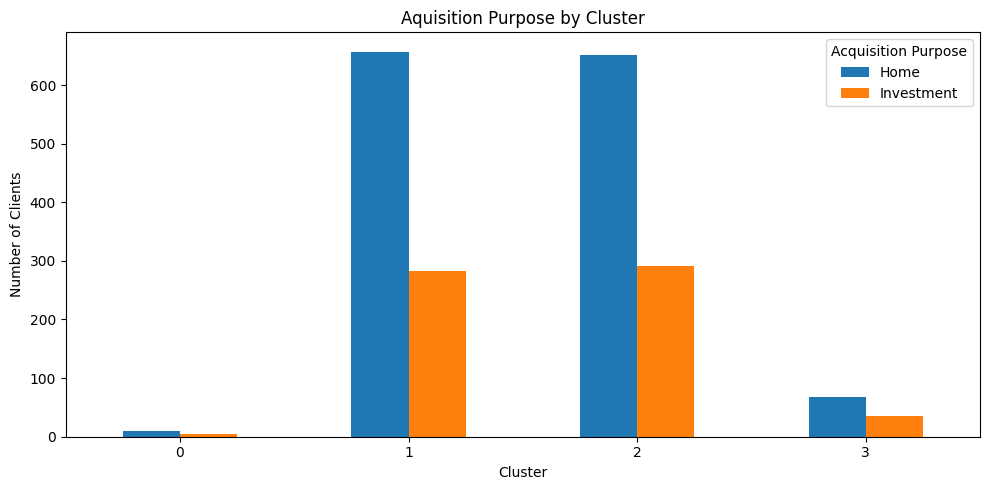

In [155]:
# Investment Purpose by Cluster

investment_cluster = pd.crosstab(
    clients['cluster'],
    clients['acquisition_purpose']
)

print("Investment Purpose by Cluster:")
display(investment_cluster)

investment_cluster.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Aquisition Purpose by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Clients')

plt.xticks(rotation=0)
plt.legend(title='Acquisition Purpose')
plt.tight_layout()
plt.show()


Loan Behavior by Cluster:


loan_applied,No,Yes
cluster,,
0,10,5
1,600,340
2,594,348
3,60,43


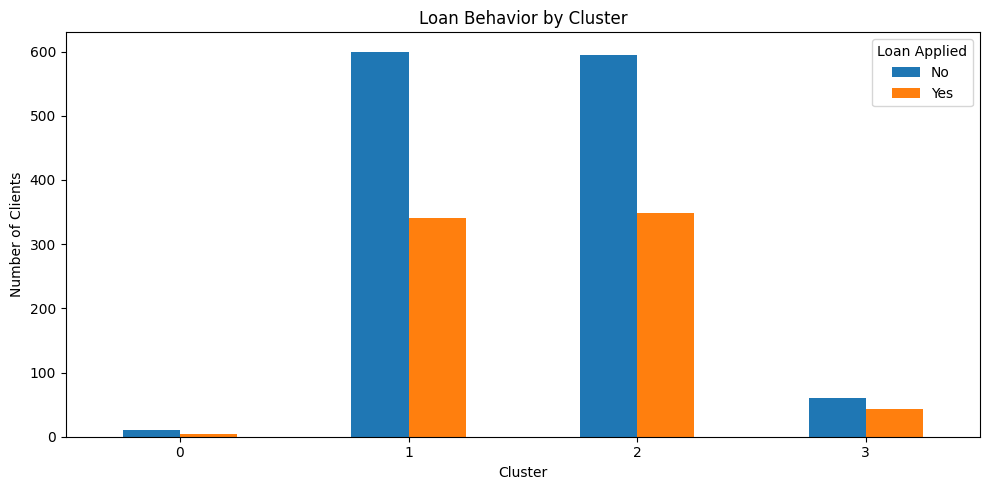

In [156]:
# Loan Behavior by Cluster

loan_cluster = pd.crosstab(
    clients['cluster'],
    clients['loan_applied']
)

print("Loan Behavior by Cluster:")
display(loan_cluster)

loan_cluster.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Loan Behavior by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Clients')

plt.xticks(rotation=0)
plt.legend(title='Loan Applied')
plt.tight_layout()
plt.show()

In [157]:
# Save final clustered client data for Streamlit

clients.to_csv('clients_clustered.csv', index=False)

print("File saved successfully!")
print("Shape:", clients.shape)
print("Columns:",
clients.columns.tolist())

File saved successfully!
Shape: (2000, 15)
Columns: ['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'date_of_birth_clear', 'age', 'cluster']


In [88]:
from google.colab import files

files.download('clients_clustered.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

# -------------------------------------------
# Page Configuration
# -------------------------------------------
st.set_page_config(
    page_title="Real Esate Buyer Intelligence",
    page_icon="🏠",
    layout="wide"
)

# ------------------------------------------------
# Load Data
# -------------------------------------------------
@st.cache_data
def load_data():
    return pd.read_csv("clients_clustered.csv")

client = load_data()

# ---------------------------------------------------
# Title
# ---------------------------------------------------
st.title("\U0001F3E0 Real Estate Buyer Segmentation & Investment Intelligence")
st.markdown(
    "Machine Learning based Buyer Segmentation for Real Estate Intelligence"
)

# ------------------------------------------------------------------------------
# Sidebar Filters
# ------------------------------------------------------------------------------
st.sidebar.header(" filters")

country_options = ["ALL"] + sorted(client["country"].dropna().unique().tolist())
region_options = ["ALL"] + sorted(client["region"].dropna().unique().tolist())
purpose_options = ["ALL"] + sorted(client["acquisition_purpose"].dropna().unique().tolist())
type_options = ["ALL"] + sorted(client["client_type"].dropna().unique().tolist())

selected_country = st.sidebar.selectbox("Country", country_options)
selected_region = st.sidebar.selectbox("Region", region_options)
selected_purpose = st.sidebar.selectbox("Acquisition Purpose", purpose_options)
selected_type = st.sidebar.selectbox("Client Type", type_options)

filtered_data = client.copy()

if selected_country != "ALL":
  filtered_data = filtered_data[filtered_data["country"] == selected_country]
if selected_region != "ALL":
  filtered_data = filtered_data[filtered_data["region"] == selected_region]
if selected_purpose != "ALL":
  filtered_data = filtered_data[filtered_data["acquisition_purpose"] == selected_purpose]
if selected_type != "ALL":
  filtered_data = filtered_data[filtered_data["client_type"] == selected_type]

# -----------------------------------------------------------------------------
# KPI Cards
# -----------------------------------------------------------------------------
st.subheader(" Buyer Segmentation Overview")

col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Buyers", len(filtered_data))
col2.metric("Clusters", filtered_data["cluster"].nunique())
col3.metric(
    "Investment Buyers", filtered_data["acquisition_purpose"].value_counts().get("Investment", 0)
)
col4.metric(
   "Loan Applicants", (filtered_data["loan_applied"] == "Yes").sum()
)

# ---------------------------------------------------------------
# Buyer Segmentation
# ---------------------------------------------------------------
st.subheader("Buyer Distribution by Cluster")

cluster_counts = filtered_data["cluster"].value_counts().sort_index().reset_index()
cluster_counts.columns = ["Cluster", "Buyers"]

fig_cluster = px.bar(
    cluster_counts,
    x="Cluster",
    y="Buyers",
    title="Number of Buyers by Clusters",
    text="Buyers"
)

st.plotly_chart(fig_cluster, use_container_width=True)

# ------------------------------------------------------
# Investor Behavior Dashboard
# ------------------------------------------------------
st.subheader(" Investor Behavior")

purpose_cluster = pd.crosstab(
    filtered_data["cluster"],
    filtered_data["acquisition_purpose"]
).reset_index()

purpose_long = purpose_cluster.melt(
    id_vars="cluster",
    var_name="Acquisition Purpose",
    value_name="Number of Buyers"
)

fig_purpose = px.bar(
    purpose_long,
    x="cluster",
    y="Number of Buyers",
    color="Acquisition Purpose",
    barmode="group",
    title="Acquisition Purpose by Cluster"
)

st.plotly_chart(fig_purpose, use_container_width=True)

# -------------------------------------------------------
# Loan Behavior
# -------------------------------------------------------
loan_cluster = pd.crosstab(
    filtered_data["cluster"],
    filtered_data["loan_applied"]
).reset_index()

loan_long = loan_cluster.melt(
    id_vars="cluster",
    var_name="Loan Applied",
    value_name="Number of Buyers"
)

fig_loan = px.bar(
    loan_long,
    x="cluster",
    y="Number of Buyers",
    color="Loan Applied",
    barmode="group",
    title="Loan Behavior by Cluster"
)

st.plotly_chart(fig_loan, use_container_width=True)

# ------------------------------------------------------
# Geographic Buyer Analysis
# ------------------------------------------------------
st.subheader("Geographic Buyer Analysis")

country_cluster = (
    filtered_data.groupby(["country", "cluster"])
    .size()
    .reset_index(name="Buyers")
)

fig_geo = px.bar(
    country_cluster,
    x="country",
    y="Buyers",
    color="cluster",
    barmode="group",
    title="Buyers by Country and Cluster"
)

st.plotly_chart(fig_geo, use_container_width=True)

# ----------------------------------------------------
# Segment Insight Panel
# ----------------------------------------------------
st.subheader("Segment Insight")

segment_summary = (
    filtered_data.groupby("cluster")
    .agg(
        Buyers=("cluster", "count"),
        Average_Age=("age", "mean"),
        Average_Satisfaction=("satisfaction_score", "mean"),
        Investment_Buyers=("acquisition_purpose",
                           lambda x: (x == "Investment").sum()),
        Loan_Applicant=("loan_applied",
                        lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

segment_summary["Investment_Percentage"] = (segment_summary["Investment_Buyers"] / segment_summary["Buyers"] * 100).round(1)
segment_summary["Average_Satisfaction"] = segment_summary[
    "Average_Satisfaction"
    ].round(2)

st.dataframe(
    segment_summary,
    use_container_width=True,
    hide_index=True
)

# ----------------------------------------------
# Cluster Profile
# ----------------------------------------------
st.subheader("Cluster Profiles")

cluster_ptofiles = {
    0: "Small buyer segment with comparatively low population.",
    1: "Large buyer segment with substantial loan and purchase activity.",
    2: "Large buyer segment with substantial loan and purchase activity.",
    3: "Smaller buyer segment with distinct buyer characteristics."
}

for cluster in sorted(filtered_data["cluster"].unique()):
    st.markdown(
        f"**Cluster {cluster}**"
        f"{cluster_ptofiles.get(cluster, 'Buyer segment identified through clustering.')}"
    )

# -----------------------------------------------------------------------------------
# Data Preview
# ------------------------------------------------------------------------------------
with st.expander("View Filtered Buyer Data"):
  st.dataframe(filtered_data, use_container_width=True)

Writing app.py


In [158]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇
up to date, audited 23 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠇

In [159]:
!pkill -f streamlit

In [160]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [161]:
%%writefile requirements.txt
streamlit
pandas
plotly

Writing requirements.txt
